# Does the QQE "momentum ignition" actually pay? ⚡
### A popular smoothed-RSI indicator — a band-cross buy signal — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Band-cross_forecasts%3F: Busted](https://img.shields.io/badge/Band--cross_forecasts%3F-Busted-8b949e?style=flat-square)

Open any trading-indicator forum and you'll find **QQE** (Quantitative Qualitative Estimation): a smoothed RSI line with a wiggly trailing band, and a simple rule — **when the smoothed RSI crosses up through the band, BUY** — sold as a *momentum ignition* that price keeps running with.

It *looks* convincing because the green crosses tend to land in uptrends. But an indicator that's a smoothed version of past price will always 'fire in uptrends' — that's circular. So we did the only fair thing: encode QQE **mechanically**, fire the band-cross rule across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from qqe import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real QQE cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 697, 'rsi_len': 14, 'sf': 5, 'qf': 4.236, 'fp_spy': '4cb5244f3990', 'h5': (5, 696, 31.5, 59, 3.72, 28.8, 2.8, 29.5, 0.28, 0.777), 'h10': (10, 696, 60.3, 62, 5.39, 57.0, 3.3, 58.3, 0.25, 0.802), 'h20': (20, 695, 100.7, 64, 7.01, 110.6, -9.9, 98.7, -0.5, 0.619), 'h60': (60, 690, 310.2, 70, 9.05, 304.1, 6.0, 308.2, 0.19, 0.846), 'per': [('SPY', 139, 103.6, 3.48, 104.8, -1.2), ('QQQ', 142, 104.5, 2.96, 150.8, -46.3), ('IWM', 140, 118.9, 2.93, 101.1, 17.8), ('DIA', 136, 84.0, 3.34, 92.0, -8.0), ('GLD', 140, 92.1, 2.37, 103.0, -10.9)], 'placebo': (103.6, 0.313, 500), 'syn': [(0.0, 107, -64.3, 46, -1.47), (0.6, 81, 703.3, 81, 9.73)]}


real QQE cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy on the QQE band-cross, do I make money? | **Yes — but only because the market goes up.** The win-rate is ~60% and the returns look great. |
| Is that *the QQE signal's* doing? | **No.** Buy on **random days** instead and you do **just as well** — once you estimate the drift properly, the cross beats random by essentially zero. |
| Does the band-cross 'forecast'? | **Not in any usable way.** Scramble the price *timing* into a look-alike random tape and the band-cross does nearly as well. The geometry isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a momentum signal. |

> A subtle trap lurks here: with **one** unlucky random comparison the QQE cross *appears* to win big. That apparent edge is just a badly-estimated baseline — pool many random draws and it vanishes. QQE is a great way to *describe* momentum, a **mirage** as a forecast.

## 1 · The claim

> *"Take RSI, smooth it, and draw an ATR-of-RSI **trailing band** around it. When the smoothed RSI **crosses above** the band, momentum has ignited — buy and ride it."*

This is **QQE** (Quantitative Qualitative Estimation), popularised by Igor Livshin and built from J. Welles Wilder's RSI + ATR machinery (the famous **4.236** factor is Wilder's). It ships as a built-in on TradingView and MetaTrader and is one of the most shared 'momentum' indicators on the forums — so: does the cross actually *forecast*?

## 2 · So what?

If the band-cross genuinely *forecast* continuation, it would be remarkable: a smoothed function of past prices predicting future ones, a clean crack in market efficiency you could trade with one line of code. That's the dream the indicator sells.

But there's a trap built into it. QQE is a **smoothed re-description of recent price** — so it 'fires in uptrends' by construction. And it's measured on a market (stock indices) that drifts **up** over time, so *any* long-only entry will look profitable. To separate the **signal** from the **tide**, we (a) build QQE by a fixed causal rule with no hindsight, and (b) compare it to buying on **random days** — with the drift estimated carefully, not from one lucky draw.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build QQE causally.** Wilder RSI (len 14), smooth it (5), and lay an ATR-of-RSI trailing band (factor 4.236) — every step uses only past bars, no look-ahead.
2. **Trade the lore.** When the smoothed RSI crosses **above** the trailing band, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**, pooled over many random draws so the drift is estimated properly. If QQE matters, the cross must beat random. *If it doesn't, the signal is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does QQE even look like? Here's SPY's smoothed RSI with its trailing band, and the band-crosses the rule would buy.

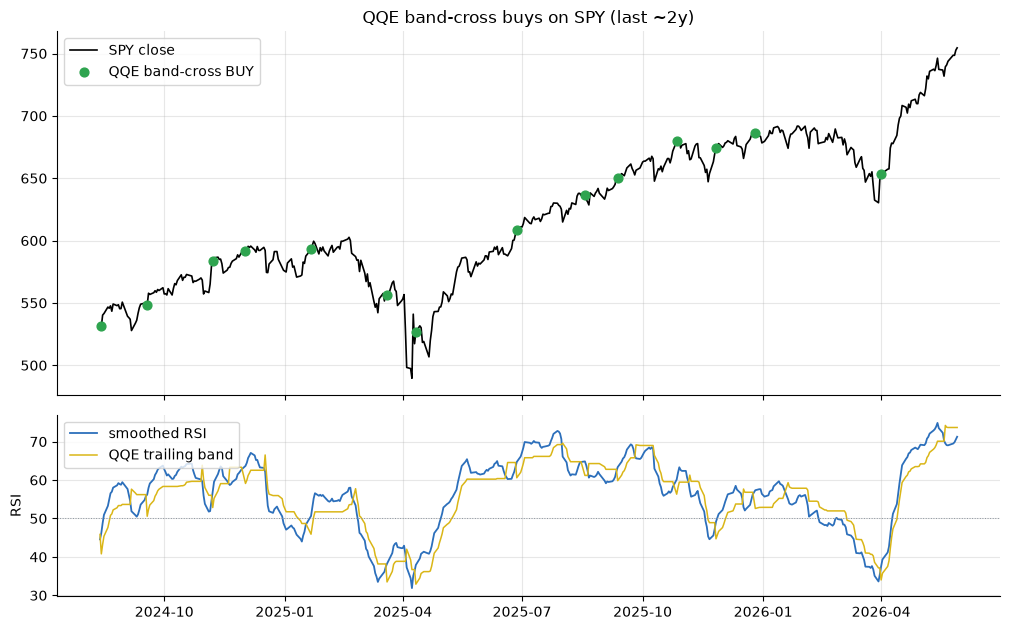

band-crosses in window: 14


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-450:]
    bands = st.qqe_bands(cl, rsi_len=R['rsi_len'], sf=R['sf'], qqe_factor=R['qf'])
    ent = st.qqe_cross_entries(cl, rsi_len=R['rsi_len'], sf=R['sf'], qqe_factor=R['qf'])
    ent = ent[ent >= seg.index[0]]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.2, 6.4), sharex=True, gridspec_kw={'height_ratios':[2,1]})
    ax1.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax1.scatter(ent, cl.reindex(ent), c=GREEN, s=40, zorder=5, label='QQE band-cross BUY')
    ax1.set_title('QQE band-cross buys on SPY (last ~2y)'); ax1.legend(loc='upper left')
    ma = bands['rsi_ma'].reindex(seg.index); ts = bands['ts'].reindex(seg.index)
    ax2.plot(seg.index, ma, c='#2c6fbb', lw=1.3, label='smoothed RSI')
    ax2.plot(seg.index, ts, c=AMBER, lw=1.1, label='QQE trailing band')
    ax2.axhline(50, c=GREY, lw=.7, ls=':'); ax2.set_ylabel('RSI'); ax2.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('band-crosses in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The cross dots land in rallies — *as a description* of momentum. The question is whether they're followed by **more** gains than you'd get on any old day. **Let's race the band-cross against random entries** at four horizons. Blue = QQE buy; grey = random days.

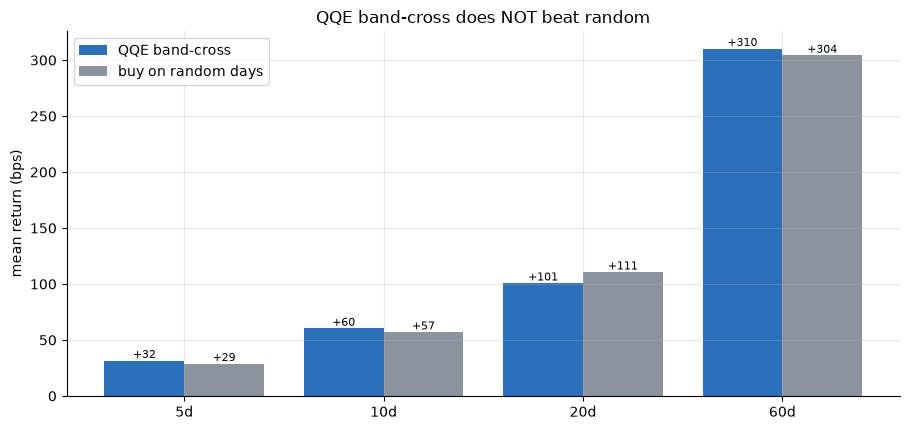

cross: [32, 60, 101, 310]
random: [29, 57, 111, 304]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    cross, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.qqe_cross_entries(c, rsi_len=R['rsi_len'], sf=R['sf'], qqe_factor=R['qf'])
            tt.append(st.forward_returns(c, e, h))
            rr.append(st.random_baseline(c, max(len(e),50), h, n_seeds=40))
        cross.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='QQE band-cross')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('QQE band-cross does NOT beat random'); ax.legend()
plt.tight_layout(); plt.show()
print('cross:', [round(v) for v in cross]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The band-cross makes money in absolute terms (**+101 bps** over 20 days) — but **random entries make essentially the same** (**+111 bps**). At every horizon the famous QQE cross is statistically a dead heat with throwing darts. The apparent edge was **the market's upward drift**, not the indicator.

**One more sanity check.** What if we scramble the price *timing* — keep the same wiggle 'shape' and volatility but shuffle *when* moves happen (a Fourier look-alike)? If the band-cross really 'forecasts', the nonsense-timing tape should do much worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.phase_scramble_placebo(c, 20, rsi_len=R['rsi_len'], sf=R['sf'], qqe_factor=R['qf'], n_draws=200, seed=471)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real QQE band-cross (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled-timing* tapes do at least as well (p={pval:.2f}).')
print('=> the QQE geometry is not doing the work.')

real QQE band-cross (SPY, 20d): +103.6 bps
... but 31% of *scrambled-timing* tapes do at least as well (p=0.31).
=> the QQE geometry is not doing the work.


About a third of the **scrambled-timing** tapes match or beat the real one (*p* = 0.31). If the band-cross genuinely keyed off real momentum, a timing scramble would collapse the result. It barely moves — because the result was never about the signal.

## 5 · The verdict

- **Signal — None.** The QQE band-cross does **not** beat buying on random days once the drift is estimated properly (the cross-vs-random difference never clears *t* = 2). The big absolute returns are the market's drift, not the indicator.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Does the band-cross forecast"? — Busted.** Scramble the timing into a look-alike tape and the result barely moves. The geometry doesn't forecast.

## 6 · Could you actually trade it?

There's nothing here to trade. The band-cross's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The QQE buy is a worse, more expensive way to be long. Costs (commissions + spread on every cross) push the already-no-edge result further negative. As a forecasting tool it doesn't pay; as a momentum *descriptor* it was never a strategy.

## 7 · Going further 🚪

- **The lucky-seed trap.** With one unlucky random comparison the QQE cross *appears* to win at *t* ≈ 3. The quants notebook shows that 'edge' is purely an under-estimated baseline — pool the seeds and it dies. A great cautionary tale for any backtest.
- **Different parameters.** Try other RSI/smoothing/factor settings — the result is robust: drift in, indicator out.
- **A real positive control.** The quants notebook plants a *genuine* post-cross continuation into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the band-cross forecasts? Show it beating a properly-pooled random baseline at **t ≥ 2** on a real tape — then we'll talk.*